In [23]:
# All of our imports shouild go here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
data = pd.read_csv("../data/raw/avocado.csv")
data.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [25]:
df = pd.DataFrame(data)
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [26]:
df.isna().sum()
# This shows we have no missing values in our dataset.

Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64

In [27]:
# Converting `Date` column to datetime format
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [28]:
# Testing to see that it properly converted to datetime format
test_diff = df['Date'].iloc[1] - df['Date'].iloc[0]
print(test_diff.days)

-7


In [29]:
# TODO: 4.2 - Need to eventually derive a new column using either `.apply()`, `.map()`, or `np.where()` 

In [64]:
#4.2 data cleaning 
#handling missing values strategy 1: dropping unnecesary column

#strategy 2: filling their numeric columns with their own median
num_of_columns= df.select_dtypes(include=["float64", "int64"]).columns
df[num_of_columns] = df[num_of_columns].fillna(df[num_of_columns].median())
#ok... think this is good yessss
#making the type conversion: converting total volume column to numeric with errors coerce
df["Total Volume"] = pd.to_numeric(df["Total Volume"], errors="coerce")
#last type conversion woooo: make "type" to categorial column
df["type"] = df["type"].astype("category")

#ok closer to finishing 4.2 
#applying np.where() to derive a new column
df["PriceLevel"] = np.where(df["AveragePrice"] > 1.50, "High", "Low")

#grouping and aggregation 
grouped = df.groupby(["region", "type"], observed=True)["AveragePrice"].agg(["mean", "count"])
grouped.head()
#also time to do the reshaping section 
pivot = grouped.reset_index().pivot_table(
    index="region",
    columns="type",
    values="mean",
    observed=True
)

pivot.head()


type,conventional,organic
region,,
Albany,1.348757,1.773314
Atlanta,1.068817,1.607101
BaltimoreWashington,1.344201,1.724260
Boise,1.076036,1.620237
Boston,1.304379,1.757396


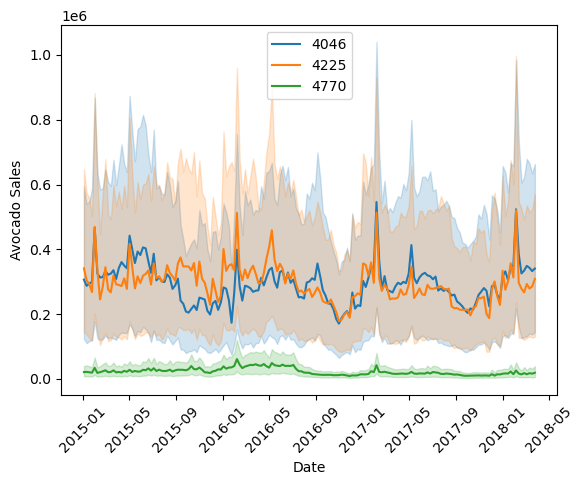

In [63]:
# 4.3 - Line plot

sns.lineplot(x='Date', y='4046', data=df, label='4046')
sns.lineplot(x='Date', y='4225', data=df, label='4225')
sns.lineplot(x='Date', y='4770', data=df, label='4770')

plt.xticks(rotation=45)

plt.ylabel("Avocado Sales")

plt.savefig("../figures/avocado_sales_by_week.svg")
plt.show()

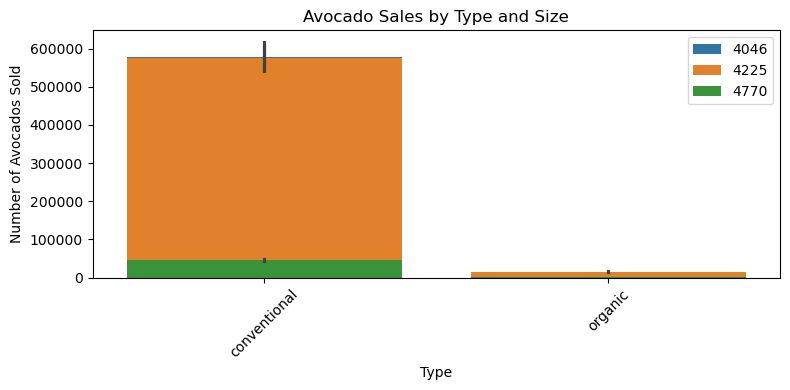

In [34]:
# 4.3 - bar plot 
plt.figure(figsize=(8,4))

sns.barplot(x='type', y='4046', data=df, label='4046')
sns.barplot(x='type', y='4225', data=df, label='4225')
sns.barplot(x='type', y='4770', data=df, label='4770')

plt.xticks(rotation=45)

plt.title("Avocado Sales by Type and Size")
plt.xlabel("Type")
plt.ylabel("Number of Avocados Sold")

plt.legend()

plt.tight_layout()
plt.savefig("../figures/bar_plot.png", dpi=300)

plt.show()

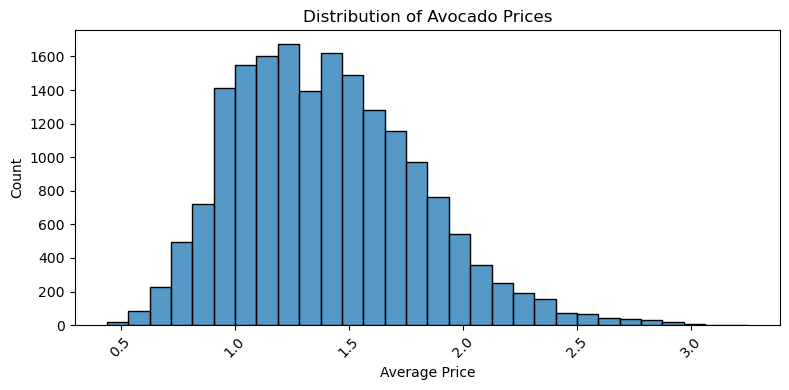

In [37]:
# 4.3 - Histogram
plt.figure(figsize=(8,4))

sns.histplot(x='AveragePrice', data=df, bins=30)

plt.xticks(rotation=45)

plt.title("Distribution of Avocado Prices")
plt.xlabel("Average Price")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("../figures/histogram.png", dpi=300)

plt.show()

C:\Users\chris\AppData\Local\Temp\ipykernel_50092\2404977188.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("type")["AveragePrice"].describe()


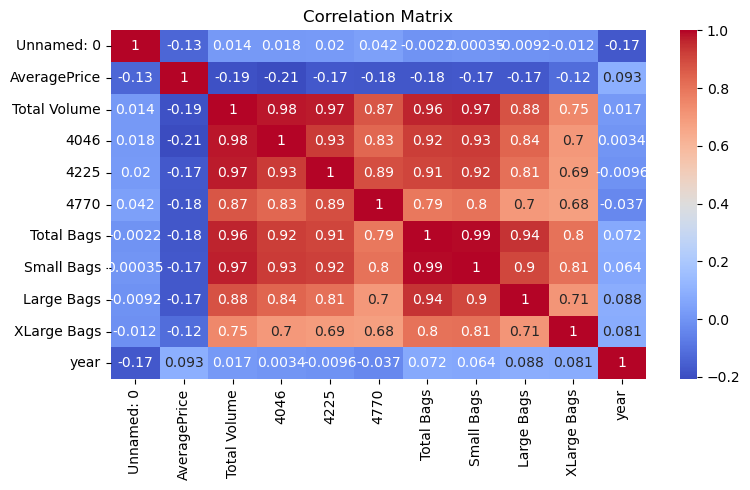

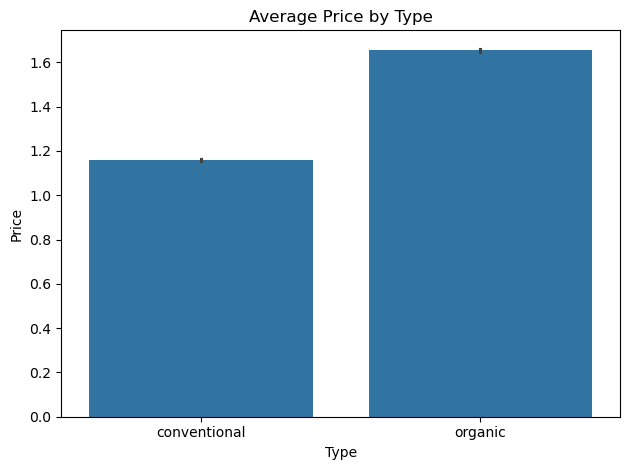

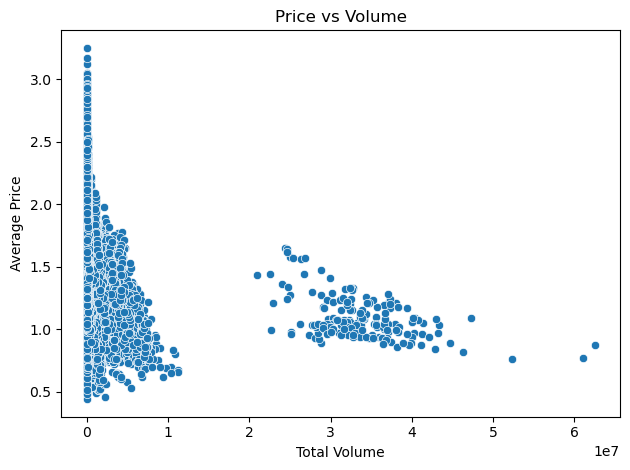

'\nThe scatter plot shows a weak relationship between total volume and price, \nindicating that higher sales volume does not strongly affect avocado prices.\n'

In [ ]:
# 4.4 EDA section 
# Descriptive Statistics
df.describe()

df["AveragePrice"].mean()
df["AveragePrice"].median()
df["AveragePrice"].min()
df["AveragePrice"].max()
df["AveragePrice"].std()

"""
The descriptive statistics summarize the distribution of avocado prices and sales. 
The average price, minimum, maximum, and standard deviation show how prices vary across the dataset.
"""

# Stats by Group
df.groupby("type", observed=True)["AveragePrice"].describe()

"""
The grouped analysis shows that organic avocados generally have higher average prices than conventional avocados.
"""

# Correlation + Heatmap
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.tight_layout()
plt.savefig("../figures/correlation.png", dpi=300)

plt.show()

"""
The correlation analysis shows relationships between numerical variables. 
Some variables, such as total volume and bag sizes, are positively correlated, meaning they tend to increase together.
"""

# Feature Exploration 1
sns.barplot(x='type', y='AveragePrice', data=df)

plt.title("Average Price by Type")
plt.xlabel("Type")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

"""
This plot shows that organic avocados are generally more expensive than conventional avocados.
"""

# Feature Exploration 2
sns.scatterplot(x='Total Volume', y='AveragePrice', data=df)

plt.title("Price vs Volume")
plt.xlabel("Total Volume")
plt.ylabel("Average Price")

plt.tight_layout()
plt.show()

"""
The scatter plot shows a weak relationship between total volume and price, 
indicating that higher sales volume does not strongly affect avocado prices.
"""

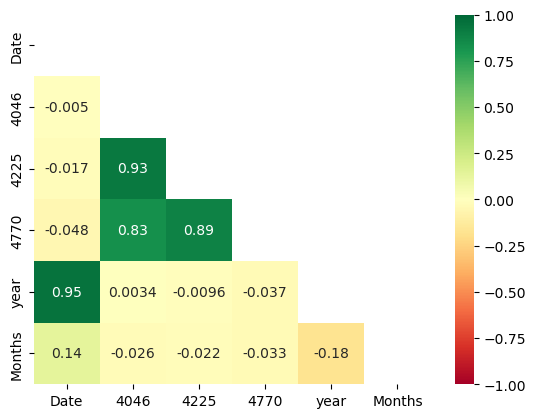

In [ ]:
# Trying to see if there is a correlation between months and avocado SKU purchased
dates_df = df
dates_df["Months"] = df["Date"].dt.month

# Dropping all irrelevant cols
dates_df = dates_df.drop(columns=["PriceLevel", "Unnamed: 0", "AveragePrice", "Total Volume", "Total Bags", "Small Bags", "Large Bags", "XLarge Bags", "type", "region"])

# Masking the diag & upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Creating the correlation matrix
corr = dates_df.corr()
sns.heatmap(corr, annot=True, mask=mask, vmin=-1, vmax=1, cmap="RdYlGn")

plt.savefig("../figures/date_correlation.svg")